In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.11.0+cu128
tiktoken version: 0.13.0


In [2]:
import os
import re
from datasets import load_dataset

# Use this instead — same data, parquet-based, no script needed
ds = load_dataset("ccdv/pubmed-summarization", split="train", streaming=True)

output_file = "pubmed_corpus.txt"
max_docs = 50_000

if not os.path.exists(output_file):
    with open(output_file, "w", encoding="utf-8") as f:
        for i, record in enumerate(ds):
            if i >= max_docs:
                break
            # this dataset has 'article' and 'abstract' fields
            text = record.get("abstract", "")
            if text:
                f.write(text.strip() + "\n\n")
    print(f"Saved {max_docs} abstracts to {output_file}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.80k [00:00<?, ?B/s]

Saved 50000 abstracts to pubmed_corpus.txt


In [3]:
# Load the full corpus first
with open("pubmed_corpus.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Total characters: {len(raw_text):,}")

# Now split the whole thing
preprocessed = re.split(r'([,.:;?_!"()\'\/<>]|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

print(f"Total tokens: {len(preprocessed):,}")
print(preprocessed[:500])

Total characters: 61,681,015
Total tokens: 10,541,693
['background', ':', 'the', 'present', 'study', 'was', 'carried', 'out', 'to', 'assess', 'the', 'effects', 'of', 'community', 'nutrition', 'intervention', 'based', 'on', 'advocacy', 'approach', 'on', 'malnutrition', 'status', 'among', 'school', '-', 'aged', 'children', 'in', 'shiraz', ',', 'iran', '.', 'materials', 'and', 'methods', ':', 'this', 'case', '-', 'control', 'nutritional', 'intervention', 'has', 'been', 'done', 'between', '2008', 'and', '2009', 'on', '2897', 'primary', 'and', 'secondary', 'school', 'boys', 'and', 'girls', '(', '7', '-', '13', 'years', 'old', ')', 'based', 'on', 'advocacy', 'approach', 'in', 'shiraz', ',', 'iran', '.', 'the', 'project', 'provided', 'nutritious', 'snacks', 'in', 'public', 'schools', 'over', 'a', '2-year', 'period', 'along', 'with', 'advocacy', 'oriented', 'actions', 'in', 'order', 'to', 'implement', 'and', 'promote', 'nutritional', 'intervention', '.', 'for', 'evaluation', 'of', 'effectivene

byte pair encoding

In [4]:
import tiktoken
tiktoken.__version__

'0.13.0'

In [5]:
import torch

In [6]:
with open("pubmed_corpus.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

simple self attn without trainable wts

using pubmed bert, toy example

In [7]:
import torch.nn as nn

X = token embeddings [256, 768]

W_Q = learned weight matrix [64, 768]

Q = query vectors [256, 64]

So yes, it uses the weights of W_Q, but the meaning is deeper:

✔ It transforms each token embedding into a query vector
✔ It learns which features matter for “searching”
✔ It is NOT just squeezing — it is a learned projection

⭐ The exact meaning
✔ The tokens stay the same
✔ But their representation changes
✔ Because W_Q learns a new coordinate system
✔ That defines how tokens search for information
So:

Q = tokens rewritten in the coordinate system that defines “search behavior.”

This is why Q is not just “squeezed tokens.”
It is tokens re‑expressed in a new semantic space.

Each row = one query token
✔ Each column = one key token
✔ Each cell (i, j) = similarity between Qᵢ and Kⱼ
attn_scores is “all queries matched with all keys.” Vⱼ is the semantic vector of token j. You do NOT use V for matching.
You only use V for retrieval.

⭐ The exact logic (clean, lookup‑style)
1️⃣ QK = lookup / similarity*
You take one query Qᵢ and compare it to all keys Kⱼ.

This gives you:

a heatmap

a relevance score

a probability distribution after softmax

This part you already understand.

2️⃣ V = the actual data you retrieve V = row data
3️⃣ context = attention × V
This is the final step:

python
context[i] = Σ_j attn_weights[i, j] * V[j]
“Context is the embedding of token i formed by mixing the V vectors of the tokens it attends to.”
✔ “So context tells me what Qᵢ becomes when it incorporates the information from the relevant Vⱼ.”
That is exactly right.

⭐ The final, cleanest version
Q = search query
K = index entries
V = row data
Q⋅K = lookup / similarity
softmax = relevance
attention × V = retrieve and combine row data
This is the entire mechanism.

⭐ The exact meaning of
“context[i] is i in terms of j”

✔ Token i starts with its own embedding
✔ It forms a query Qᵢ
✔ It compares itself to all other tokens’ keys Kⱼ
✔ It gets a relevance score for each token j
✔ It then pulls the Vⱼ vectors (the actual data)
✔ And forms a weighted mixture of those Vⱼ vectors
So:

context[i] = the new embedding of token i, expressed in terms of the V vectors of the tokens it attends to.

class SelfAttentionFromBERT(nn.Module):
    def __init__(self, embed_dim=768, d_k=64, d_v=64):
        super().__init__()
        self.W_Q = nn.Linear(embed_dim, d_k, bias=False)
        self.W_K = nn.Linear(embed_dim, d_k, bias=False)
        self.W_V = nn.Linear(embed_dim, d_v, bias=False)

    def forward(self, x):
        Q = self.W_Q(x)   # [1, 256, 64]
        K = self.W_K(x)   # [1, 256, 64]
        V = self.W_V(x)   # [1, 256, 64]

        attn_scores = torch.matmul(Q, K.transpose(-2, -1))  # [1, 256, 256]
        attn_scores = attn_scores / (Q.shape[-1] ** 0.5)

        attn_weights = torch.softmax(attn_scores, dim=-1)   # [1, 256, 256]

        context = torch.matmul(attn_weights, V)             # [1, 256, 64]
        return context


Each of the 256 context vectors is the final representation of a token after it attends to all other tokens using Q, K, and V.

FIRST: What does [256, 64] mean?
Yes:

256 vectors

each vector has 64 numbers

But what does one of those 64‑dim vectors mean?

To answer that, we go step‑by‑step through the pipeline.

⭐ STEP 1 — You build a heatmap: [256 × 256]
This comes from:

Code
attn_scores = Q @ K^T
attn_weights = softmax(attn_scores)
So:

Row i = how much token i attends to every token j

256 weights per row

each row sums to 1

This is your attention heatmap.

⭐ STEP 2 — You have V: [256 × 64]
Each token j has a 64‑dim value vector:

Code
V[0] → 64 numbers  
V[1] → 64 numbers  
...
V[255] → 64 numbers
These are the payload vectors.

⭐ STEP 3 — Now the key part:
context[i] = heatmap_row[i] × V
This is EXACTLY what you said:

“maybe it started as a 256×256 heatmap of Q and K, then got combined with V and now it’s a 64‑number vector”

YES.
That is literally correct.

Let’s make it explicit.

⭐ PICK ONE CONTEXT VECTOR
Say you pick:

Code
context_vectors[0]   # shape [64]
This vector is:

✔ Take heatmap row 0 (256 weights)
✔ Multiply each weight by V[j] (a 64‑dim vector)
✔ Add all 256 weighted V vectors together
✔ Result = one 64‑dim vector
So:

The first context vector is a weighted mixture of ALL 256 V vectors, using the first heatmap row as weights.

That’s why it has 64 numbers — because V has 64 numbers.

⭐ THE CLEANEST POSSIBLE SUMMARY
Let’s rewrite your sentence correctly:

“A context vector is:
one row of the 256×256 heatmap multiplied by the 256×64 V matrix, producing a 64‑dim vector.”

YES.
That is EXACTLY what it is.

context = heatmap  ×  V
         [256×256] × [256×64]
         ---------------------
               [256×64]


You have:

Q = [1, 256, 64]

K = [1, 256, 64]

When you compute:

python
attn_scores = Q @ K.transpose(-2, -1)
You are doing:

Code
[1, 256, 64]  @  [1, 64, 256]  →  [1, 256, 256]
This means:

For each of the 256 tokens,

You compute similarity with all 256 tokens,

Producing a 256×256 attention matrix

And the batch dimension stays as 1.

So [1, 256, 256] =
1 batch × 256 query positions × 256 key positions

4. What unsqueeze(0) actually does
unsqueeze(dim) inserts a new dimension of size 1.

Example:

Code
Before: [256, 256]
After unsqueeze(0): [1, 256, 256]
It’s like saying:

“Make this mask apply to the whole batch.”

Without this, PyTorch would throw a shape mismatch error.

In [8]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        # For inputs where `num_tokens` exceeds `context_length`, this will result in errors
        # in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec



In [9]:
class MultiHeadAttentionWrapper(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


#torch.manual_seed(123)

#context_length = batch.shape[1] # This is the number of tokens
#d_in, d_out = 768, 64
#mha = MultiHeadAttentionWrapper(
   # d_in, d_out, context_length, 0.0, num_heads=2
#)

#context_vecs = mha(batch)

#print(context_vecs)
#print("context_vecs.shape:", context_vecs.shape)

You can think of this chapter as saying:

“You’ve built self‑attention in isolation. Now here’s how it lives inside a full GPT‑style model.”

So for you, it means:

you’re ready to wrap your QKV + self‑attention into a TransformerBlock

then stack blocks and add an output head like he does

so your PubMed model stops being “just attention experiments” and becomes an actual language model architecture

Let’s make that concrete.

1. What this means for you
Right now you have:

PubMed tokens → embeddings

self‑attention → context vectors [seq_len, d_model]

The book’s model adds the missing pieces:

Token embeddings (nn.Embedding)

Positional embeddings

Stack of Transformer blocks (each with MHA + MLP)

Final LayerNorm

Output head: Linear(d_model → vocab_size) → logits

So the message for you is:

Take your self‑attention and plug it into a TransformerBlock like this, then stack it like DummyGPTModel.

2. Minimal plan to implement it yourself
Here’s the path, step‑by‑step, in your PubMed setting.

Step 1 — Define a real TransformerBlock
Replace DummyTransformerBlock with something like:

python
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, drop_rate):
        super().__init__()
        self.attn = YourMultiHeadAttention(d_model, n_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(drop_rate),
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [batch, seq, d_model]
        attn_out = self.attn(self.ln1(x))      # self‑attn with your QKV
        x = x + attn_out                       # residual
        mlp_out = self.mlp(self.ln2(x))
        x = x + mlp_out                        # residual
        return x
Your existing self‑attention (Q/K/V + heatmap × V) becomes YourMultiHeadAttention.

Step 2 — Swap it into the GPT skeleton
In DummyGPTModel, change:

python
self.trf_blocks = nn.Sequential(
    *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
)
to:

python
self.trf_blocks = nn.Sequential(
    *[TransformerBlock(cfg["emb_dim"], cfg["n_heads"], cfg["drop_rate"])
      for _ in range(cfg["n_layers"])]
)
Now the model is:

embeddings

positional embeddings

N × (self‑attn + MLP)

final norm

output head

Exactly GPT‑style.

Step 3 — Use your own tokenizer / corpus
For PubMed:

keep the same structure

just change:

tokenizer (PubMed/BPE)

vocab_size

maybe context_length

The rest of the architecture is identical.

3. What you get once you do this
Once you plug your attention into this skeleton, you now have:

a real transformer LM over PubMed text

that:

takes token IDs

embeds them

runs them through stacked attention+MLP blocks

outputs logits over vocab at each position

From here you can:

train from scratch on PubMed

or later load pretrained weights (like he does with GPT‑2)

The model turns each token into a 768‑dim hidden vector.
The output head converts that into 50k logits (one per vocab token).
Softmax turns those logits into probabilities.
768-d hidden vector
↓ Linear(768→50257)
50257-d logits
↓ softmax
50257-d probabilities
1. The model outputs logits (50k numbers)
2. Softmax → probabilities
3. You pick the next token ID (e.g., 345)
4. You feed that token ID back into the model
5. The model turns that token ID into a 768‑dim embedding
6. THAT embedding becomes the next Q/K/V source

23 june
building  gpt model

notes: ✔ ReLU says:
“If x > 0, keep it. If x < 0, kill it.”

Very harsh. Too binary.

✔ Sigmoid says:
“Squash everything between 0 and 1.”

Too smooth. Too slow.

✔ GELU says:“Let important values pass fully,
let unimportant values pass partially,
and gently suppress noise.”

Attention does cross‑token mixing:

“Which other words should I look at?”

But attention alone cannot:

build nonlinear features

detect patterns

transform meaning

compress or expand representations

That’s what the MLP does.

✔ Attention = communication
✔ MLP = thinking
Every transformer block needs both.

2. Why is there an MLP after attention?
This is the part most people misunderstand.

✔ Attention ≠ full intelligence
Attention only mixes information between tokens.

It answers:

“Which other words should I look at?”

But attention cannot transform the meaning of each token deeply.

✔ The MLP is the “thinking” part
The MLP operates per token, independently:

Code
Linear → GELU → Linear
This lets the model:

build nonlinear features

detect patterns

transform representations

create abstractions

Attention = “who should I look at?”
MLP = “what should I think about after looking?”

Both are required.

In [10]:
import torch
import torch.nn as nn


class GPTModel1(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(tokenizer.vocab_size, cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])


        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = MyLayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(
            cfg["emb_dim"], tokenizer.vocab_size
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = MyLayerNorm(cfg["emb_dim"])
        self.attn = MultiHeadAttentionWrapper(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"] // cfg["n_heads"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            num_heads=cfg["n_heads"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ln2 = MyLayerNorm(cfg["emb_dim"])
        self.mlp = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        # 1. Attention block
        x = x + self.attn(self.ln1(x))   # residual connection

        # 2. Feedforward block
        x = x + self.mlp(self.ln2(x))    # residual connection

        return x


class MyLayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))   # γ
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # β

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # GPT‑2 uses biased variance
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * x_norm + self.shift


In [11]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}


now i need token ids not token embeddings to feed into this model so ill create them as such

In [12]:
from transformers import AutoTokenizer, AutoModel
import torch

In [13]:
#getting token ids.
tokenizer = AutoTokenizer.from_pretrained("NeuML/pubmedbert-base-embeddings")
token1 = tokenizer.encode(raw_text)
token1 = torch.tensor(token1, dtype=torch.long)


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/706k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

raw PubMed text → token IDs → batches → GPTModel1

In [14]:
def make_batch(tokens, seq_len, batch_size):
    ix = torch.randint(len(tokens) - seq_len - 1, (batch_size,))
    x = torch.stack([token1[i:i+seq_len] for i in ix])
    y = torch.stack([token1[i+1:i+seq_len+1] for i in ix])
    return x, y


In [15]:
x, y = make_batch(token1, seq_len=256, batch_size=2)

model = GPTModel1(GPT_CONFIG_124M)
logits = model(x)

print(logits.shape)   # [2, 256, 50257]


torch.Size([2, 256, 30522])


In [16]:
torch.manual_seed(123)
model = GPTModel1(GPT_CONFIG_124M)
model.eval();

In [17]:
abstracts = raw_text.split("\n\n")
print(abstracts[0])


background : the present study was carried out to assess the effects of community nutrition intervention based on advocacy approach on malnutrition status among school - aged children in shiraz , iran.materials and methods : this case - control nutritional intervention has been done between 2008 and 2009 on 2897 primary and secondary school boys and girls ( 7 - 13 years old ) based on advocacy approach in shiraz , iran . 
 the project provided nutritious snacks in public schools over a 2-year period along with advocacy oriented actions in order to implement and promote nutritional intervention . for evaluation of effectiveness of the intervention growth monitoring indices of pre- and post - intervention were statistically compared.results:the frequency of subjects with body mass index lower than 5% decreased significantly after intervention among girls ( p = 0.02 ) . 
 however , there were no significant changes among boys or total population . 
 the mean of all anthropometric indices 

In [18]:
import random

sample_text = random.choice(abstracts)
print(sample_text[:500])


we sequenced 8 melanoma exomes to identify novel somatic mutations in metastatic melanoma . 
 focusing on the map3k family , we found that 24% of melanoma cell lines have mutations in the protein - coding regions of either map3k5 or map3k9 . 
 structural modelling predicts that mutations in the kinase domain may affect the activity and regulation of map3k5/9 protein kinases . 
 the position of the mutations and loss of heterozygosity of map3k5 and map3k9 in 85% and 67% of melanoma samples , resp


In [19]:
vocab_size = tokenizer.vocab_size
print(vocab_size)

30522


In [20]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_next_tokens(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):

        logits = model(idx)              # [1, seq_len, vocab_size]
        last_logits = logits[:, -1, :]   # [1, vocab_size]

        probs = F.softmax(last_logits, dim=-1)
        next_id = torch.argmax(probs, dim=-1, keepdim=True)

        idx = torch.cat([idx, next_id], dim=1)

    return idx


In [21]:
import re

def split_into_sentences(text):
    # crude but effective biomedical sentence splitter
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s for s in sentences if len(s) > 0]


In [22]:
import random
random.seed(123)
torch.manual_seed(123)
sample_text = random.choice(abstracts)
sentences = split_into_sentences(sample_text)

if len(sentences) < 2:
    # pick another abstract if too short
    sample_text = random.choice(abstracts)
    sentences = split_into_sentences(sample_text)

first_sentence = sentences[0]
second_sentence = sentences[1]

print("Sentence 1:", first_sentence)
print("Sentence 2:", second_sentence)


Sentence 1: background : the effect of ovarian hyperstimulation syndrome ( ohss ) on pregnancy outcomes of in vitro fertilization ( ivf ) patients is still ambiguous .
Sentence 2: this study aimed to analyze pregnancy outcomes of ivf with or without ohss in chinese patients.methods:a retrospective cohort study was undertaken to compare pregnancy outcomes between 190 women with ohss and 197 women without ohss .


In [23]:
ids = tokenizer.encode(second_sentence, return_tensors="pt")
print("Input token IDs:", ids)

Input token IDs: tensor([[    2,  2052,  2161,  6822,  1942,  7125,  5284,  3685,  1927, 18304,
          1956,  2014,  2979,  5622,  5590,  1922,  7185,  2132,    18,  2860,
            30,    43,  6968,  4382,  2161,  1982, 10466,  1942,  5175,  5284,
          3685,  2192, 11981,  3089,  1956,  5622,  5590,  1930,  5876,  3089,
          2979,  5622,  5590,    18,     3]])


In [24]:
import torch
import torch.nn.functional as F

torch.manual_seed(123)

@torch.no_grad()
def generate_next_tokens(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        logits = model(idx)              # [1, seq_len, vocab_size]
        last_logits = logits[:, -1, :]   # [1, vocab_size]

        probs = F.softmax(last_logits, dim=-1)
        next_id = torch.argmax(probs, dim=-1, keepdim=True)

        idx = torch.cat([idx, next_id], dim=1)

    return idx


In [25]:
new_ids = generate_next_tokens(model, ids, max_new_tokens=10)


In [26]:
decoded_output = tokenizer.decode(new_ids[0])
print("\nGenerated continuation:\n", decoded_output)



Generated continuation:
 [CLS] this study aimed to analyze pregnancy outcomes of ivf with or without ohss in chinese patients. methods : a retrospective cohort study was undertaken to compare pregnancy outcomes between 190 women with ohss and 197 women without ohss. [SEP] ntr bioreactor retroviral ibm advocateostomy kon rpmidis mood


In [27]:
inputs = ids[:, :-1]      # all except last
targets = ids[:, 1:]      # all except first


In [28]:
logits = model(inputs)   # shape: [1, seq_len-1, vocab_size]
print(logits.shape)

torch.Size([1, 44, 30522])


In [29]:
log_probas = torch.log_softmax(logits, dim=-1)
# targets shape: [1, seq_len-1]
# log_probas shape: [1, seq_len-1, vocab_size]

correct_log_probas = log_probas[0, torch.arange(targets.size(1)), targets[0]]
print(correct_log_probas)

tensor([-10.1752,  -9.7676, -10.8977, -10.4432, -10.3510,  -9.2465, -11.5103,
        -10.9212, -10.3321, -10.9735, -10.0067, -10.2259, -10.6308, -10.5041,
        -10.2186, -10.8480,  -9.4539,  -9.9637, -10.6381,  -9.4539, -10.2003,
        -10.8741, -10.7425,  -9.1627, -10.9035,  -9.9276,  -9.7822, -10.5233,
        -10.4986, -10.4206, -11.5519, -11.0440, -10.3553,  -9.4327, -11.8302,
        -10.9747, -10.2343, -11.0638, -11.3019, -10.6983, -10.5372, -11.0582,
         -9.5440,  -9.3188], grad_fn=<IndexBackward0>)


log_probas[0,
           [0, 1, 2, ..., 43],
           [correct_id_0, correct_id_1, ..., correct_id_43]]

model produces logits → probabilities for all vocab tokens

you extract the probability of the correct token

you compare predicted vs. target

you compute cross‑entropy loss

✔ log_probas[0]
Select batch 0 → shape becomes:

Code
[44, vocab_size]
✔ torch.arange(targets.size(1))
Creates:

Code
[0, 1, 2, ..., 43]
These are the token positions.

✔ targets[0]
This is the vector of correct next token IDs:

Code
[2052, 12211, 5868, ..., correct_id_43]
✔ Putting it together
You are selecting:

Code
log_probas[0, position, correct_token_id]
For each of the 44 positions.

This gives you:

Code
tensor([
  log p(correct token at pos 0),
  log p(correct token at pos 1),
  ...
  log p(correct token at pos 43)
])
Shape:

Code
[44]

In [30]:
avg_log_probas = correct_log_probas.mean()
print("Average log probability:", avg_log_probas)

# 6. Negative average log-probability = cross-entropy loss
cross_entropy_loss = -avg_log_probas
print("Cross-entropy loss:", cross_entropy_loss)

Average log probability: tensor(-10.4214, grad_fn=<MeanBackward0>)
Cross-entropy loss: tensor(10.4214, grad_fn=<NegBackward0>)


In [31]:
logits_flat = logits.flatten(0, 1)   # [seq_len-1, vocab_size]
targets_flat = targets.flatten()     # [seq_len-1]

# Compute cross-entropy loss
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.4214, grad_fn=<NllLossBackward0>)


In [32]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(33571.3633, grad_fn=<ExpBackward0>)


In [33]:
from torch.utils.data import Dataset, DataLoader
import torch
class GPTDatasetPubMed(Dataset):
    def __init__(self, token_ids, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        assert len(token_ids) > max_length

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk  = token_ids[i : i + max_length]
            target_chunk = token_ids[i+1 : i + max_length + 1]

            self.input_ids.append(input_chunk)
            self.target_ids.append(target_chunk)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


In [34]:
def create_dataloader_pubmed(token_ids, batch_size=4,
                             max_length=256, stride=128,
                             shuffle=True, drop_last=True,
                             num_workers=0):

    dataset = GPTDatasetPubMed(token_ids, max_length, stride)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )


In [35]:
train_ratio = 0.90
split_idx = int(train_ratio * len(token1))

train_data = token1[:split_idx]
val_data   = token1[split_idx:]


In [36]:
torch.manual_seed(123)

train_loader = create_dataloader_pubmed(
    train_data,
    batch_size=2,
    max_length=256,
    stride=256,
    num_workers=2,
    drop_last=True,
    shuffle=True
)

val_loader = create_dataloader_pubmed(
    val_data,
    batch_size=2,
    max_length=256,
    stride=256,
    drop_last=False,
    shuffle=False
)



In [37]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Streaming output truncated to the last 5000 lines.
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torc

In [38]:
print("DEBUG:")
for batch in train_loader:
    print(type(batch))
    print(len(batch))
    print(batch)
    break


DEBUG:
<class 'list'>
2
[tensor([[ 3181,    18,  2038,  2481,  2052,  3087,  1930,    43,  3043,  1927,
          1920,  4431,  1927,  1920,  2118,  1972,  1040,  2210,  1927, 11679,
          1922, 22786,    18,  6804,  1930,  6322,  3879,  2112,  1998,  6416,
          2007,  9138,  2413, 11570,  2460, 21796, 23830,  1922,  2154,  2321,
          1920,  5989,  1930,  1920,  5128,  3394,  8882,    17, 13542,  1927,
         12315,    18,  3410,    16, 10484,    16,  2858,  4401,  6897,    12,
          5483,    33,  3480,  2943,    13,  1985,  5674,  1922,  4258, 10517,
          1990,  5759,  5845, 13950,  2800,    16,  1930,  1920,  3864,  4061,
          2032,  2522,  1942, 13562,  3206,  6579,  3154, 21834, 21359,    18,
         18766,  4995,  5441,  1930,  8517,  4941,    12,  3844,    17, 26878,
            66,    17,  6451,  8517,    16,  4995,  7876,    16,  1930,  4995,
          3844,    17,  3257,  8517,    13,  1985,  2251,  1942, 22080,  2310,
          3076,  5128,    1

In [39]:
train_tokens = train_data.numel()
val_tokens   = val_data.numel()

print("Train split tokens:", train_tokens)
print("Val split tokens:", val_tokens)
print("Total tokens:", train_tokens + val_tokens)


Train split tokens: 10329042
Val split tokens: 1147672
Total tokens: 11476714


In [40]:
context_length = GPT_CONFIG_124M["context_length"]

if train_data.numel() < context_length + 1:
    print("Not enough tokens for training loader.")

if val_data.numel() < context_length + 1:
    print("Not enough tokens for validation loader.")



In [41]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)



Training tokens: 10328576
Validation tokens: 1147648
All tokens: 11476224


In [42]:
context_length = GPT_CONFIG_124M["context_length"]

# Raw token counts
train_raw = train_data.numel()
val_raw   = val_data.numel()

print("Raw train tokens:", train_raw)
print("Raw val tokens:", val_raw)

if train_raw < context_length + 1:
    print("Not enough tokens for training loader.")

if val_raw < context_length + 1:
    print("Not enough tokens for validation loader.")

# Actual tokens fed into model
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)


Raw train tokens: 10329042
Raw val tokens: 1147672
Training tokens: 10328576
Validation tokens: 1147648
All tokens: 11476224


In [43]:
def calc_loss_batch(input_batch, target_batch, model, device):
    # Move to GPU/CPU
    input_batch  = input_batch.to(device)
    target_batch = target_batch.to(device)

    # Forward pass: logits shape [B, T, V]
    logits = model(input_batch)

    # Flatten batch + sequence dims → shape [B*T, V]
    logits_flat  = logits.flatten(0, 1)

    # Flatten targets → shape [B*T]
    targets_flat = target_batch.flatten()

    # Cross-entropy over all tokens
    loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

    return loss


What calc_loss_loader does (the part you asked about)
This function does NOT compute a new kind of loss.

It simply:

✔ loops through the dataloader
✔ calls calc_loss_batch for each batch
✔ adds all the losses together
✔ divides by number of batches
✔ returns the average loss
That’s it.

In [44]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    if len(data_loader) == 0:
        return float("nan")

    # If num_batches is None → use full loader
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    total_loss = 0.0

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break

        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

        # --- Progress printing every 500 batches ---
        if i % 500 == 0:
            print(f"Processed {i}/{num_batches} batches "
                  f"({(i/num_batches)*100:.2f}% complete)")

    print(f"Processed all {num_batches} batches.")
    return total_loss / num_batches



In [45]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")

Using cuda device.


In [46]:
from itertools import islice
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=200)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=200)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Processed 0/200 batches (0.00% complete)
Processed all 200 batches.
Processed 0/200 batches (0.00% complete)
Processed all 200 batches.
Training loss: 10.479904608726502
Validation loss: 10.477866997718811


In [47]:
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 20173
Val batches: 2242


In [48]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def text_to_token_ids(text, tokenizer):
    # Returns a 1D tensor of token IDs (no batch dim)
    encoded = tokenizer.encode(text, add_special_tokens=False)
    return torch.tensor(encoded, dtype=torch.long)
def token_ids_to_text(token_ids, tokenizer):
    # token_ids: 1D tensor of ints
    ids = token_ids.tolist()
    return tokenizer.decode(ids, skip_special_tokens=True)

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        # --- TOP‑K FILTERING ---
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val,
                                 torch.tensor(float("-inf")).to(logits.device),
                                 logits)

        # --- TEMPERATURE SCALING ---
        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


def generate_and_print_sample(model, tokenizer, device, start_context,
                              temperature=0.7, top_k=40):

    model.eval()
    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    encoded = encoded.unsqueeze(0)   # NEW: batch dimension

    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size,
            temperature=temperature,
            top_k=top_k
        )

    decoded_text = token_ids_to_text(token_ids[0], tokenizer)
    print(decoded_text.replace("\n", " "))

    model.train()


In [49]:
import torch

In [51]:
torch.manual_seed(123)
model = GPTModel1(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 1
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=1000, eval_iter=1,
    start_context = "The patient presented with acute respiratory distress", tokenizer=tokenizer
)

Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Ep 1 (Step 000000): Train loss 9.611, Val loss 9.566
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Ep 1 (Step 001000): Train loss 5.975, Val loss 6.232
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Ep 1 (Step 002000): Train loss 6.627, Val loss 6.023
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Ep 1 (Step 003000): Train loss 5.257, Val loss 5.935
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Ep 1 (Step 004000): Train loss 5.120, Val loss 5.803
Processed 0/1 batches (0.00% complete)
Processed all 1 batches.
Processed 0/1 batches (0.00% co

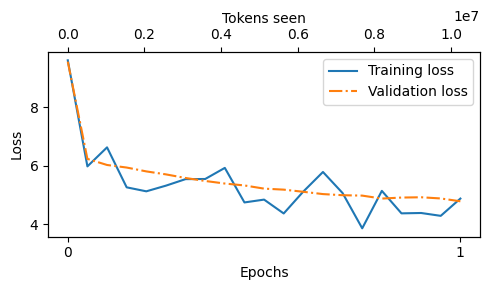

In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [53]:
torch.save(model.state_dict(), "model.pth")

In [54]:
model = GPTModel1(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cuda


In [55]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [57]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel1(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();